     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]


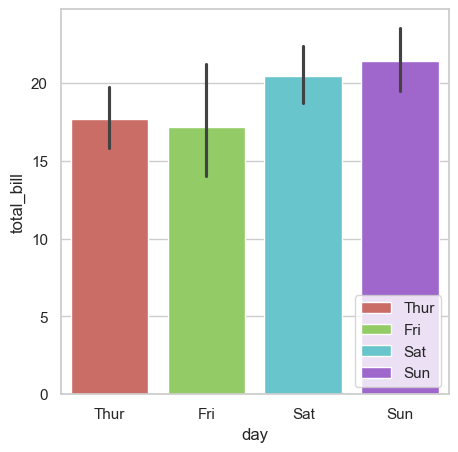

C:\Users\user\AppData\Local\Temp\ipykernel_61248\715805383.py:22: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df,


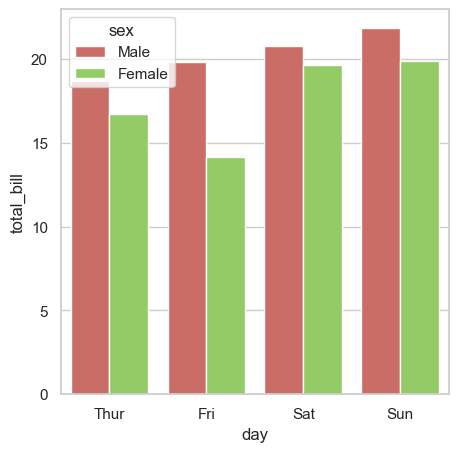

sex        Male     Female
day                       
Thur  18.714667  16.715312
Fri   19.857000  14.145556
Sat   20.802542  19.680357
Sun   21.887241  19.872222


C:\Users\user\AppData\Local\Temp\ipykernel_61248\715805383.py:32: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df2 = df.pivot_table(index='day',


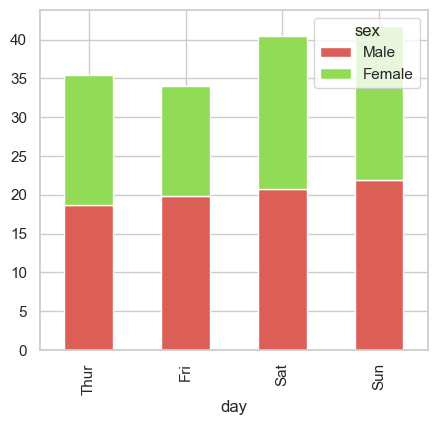

In [8]:
# 8-1 
import seaborn as sns
import matplotlib.pyplot as plt
df= sns.load_dataset('tips')
df.head()
print(df)

#그래프 테마 설정
sns.set_theme(style="whitegrid", rc = {"figure.figsize": (5, 5)})
sns.set_palette('hls', 4)
sns.barplot(data=df,
            x='day',
            y='total_bill',
            estimator='mean',
            hue='day',
            legend=True
            )
plt.legend(loc="lower right")
plt.show()

# 요일별 성별 평균 지불 금액
sns.barplot(data=df,
            x='day',
            y='total_bill',
            estimator='mean',
            hue='sex',
            ci=None
            )
plt.show()

#누적 막대그래프
df2 = df.pivot_table(index='day',
                     columns='sex',
                     values='total_bill',
                     aggfunc='mean'
                     )

print(df2)
df2.plot.bar(stacked=True)
plt.subplots_adjust(bottom=0.2)
plt.show()

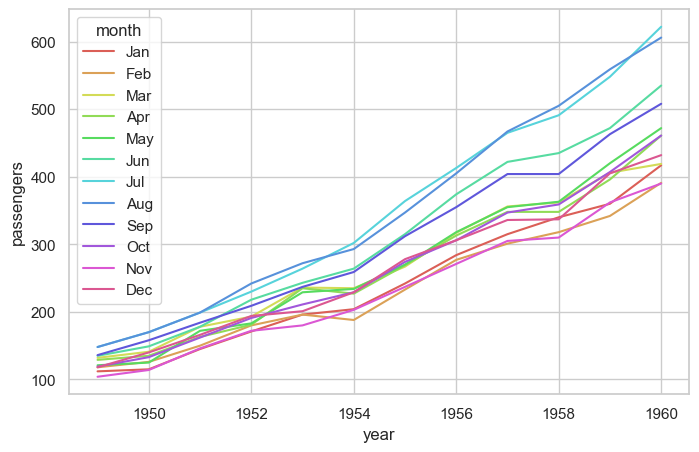

In [ ]:
#8-2
import seaborn as sns
import matplotlib.pyplot as plt

df= sns.load_dataset('flights')
df.head()

sns.set_theme(style="whitegrid", rc={"figure.figsize": (8, 5)})
sns.set_palette('hls', 12)

sns.lineplot(data=df,
             x='year',
             y='passengers',
             hue='month'
             )

plt.show()

         날짜  평균기온  평균강수량  평균일조시간  평균습도  평균순간최대풍속
0  20231231   2.1    4.7     0.6  95.5       8.3
1  20231230   0.6   13.1     0.0  92.0       6.9
2  20231229   1.3    0.0     1.8  71.0       5.7
3  20231228   1.2    0.0     8.1  69.5       8.0
4  20231227   1.5    0.0     8.2  76.6       4.7
         날짜  평균기온  평균강수량  평균일조시간  평균습도  평균순간최대풍속  month
0  20231231   2.1    4.7     0.6  95.5       8.3     12
1  20231230   0.6   13.1     0.0  92.0       6.9     12
2  20231229   1.3    0.0     1.8  71.0       5.7     12
3  20231228   1.2    0.0     8.1  69.5       8.0     12
4  20231227   1.5    0.0     8.2  76.6       4.7     12
[0, 2, 4, 5, 7, 8, 10, 11, 9, 6, 3, 1]


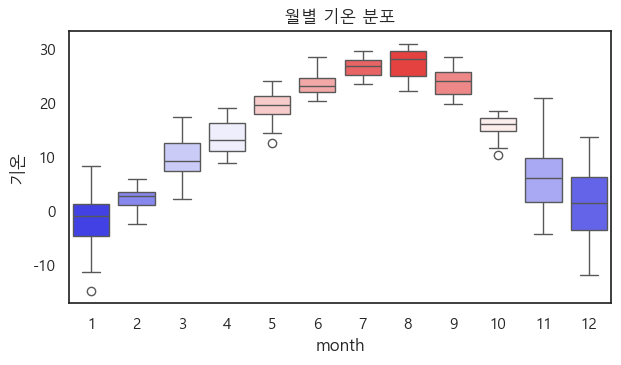

               날짜       평균기온      평균강수량    평균일조시간       평균습도  평균순간최대풍속
month                                                                 
1      20230116.0  -1.522581   1.545161  6.158065  63.303226  8.038710
2      20230214.5   2.300000   0.035714  7.078571  58.900000  7.475000
3      20230316.0   9.780645   0.338710  7.735484  51.241935  8.612903
4      20230415.5  13.800000   3.230000  6.076667  59.933333  9.546667
5      20230516.0  19.522581   5.019355  7.600000  62.493548  8.893548
6      20230615.5  23.383333   6.520000  6.503333  72.433333  7.970000
7      20230716.0  26.706452  14.835484  4.712903  81.074194  8.712903
8      20230816.0  27.187097   9.616129  5.035484  76.351613  7.951613
9      20230915.5  23.663333   4.483333  5.236667  73.483333  6.980000
10     20231016.0  15.793548   1.000000  6.732258  66.477419  6.816129
11     20231115.5   6.796667   2.730000  5.730000  64.503333  9.203333
12     20231216.0   1.116129   2.770968  4.587097  69.348387  7.929032


In [17]:
# 8-3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df=pd.read_csv('data/seoul_temp.csv')
print(df.head())
df['month'] = (df.날짜 - 20230000) // 100
print(df.head())

sns.set_theme(style="white", rc={"figure.figsize": (7, 4)})
tmp = df.groupby('month').mean()
rank = tmp['평균기온'].rank() - 1
rank = rank.astype(int).to_list()
print(rank)

mycolor = sns.color_palette('bwr', 12)
mycolor = pd.Series(mycolor)[rank].to_list()

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

sns.boxplot(data=df,
            x='month',
            y='평균기온',
            hue='month',
            legend=None,
            palette=mycolor
            ).set(title='월별 기온 분포')

plt.ylabel('기온')
plt.subplots_adjust(bottom=0.2)
plt.show()

print(tmp)

        state  murder  forcible_rape  robbery  aggravated_assault  burglary  \
0     Alabama     8.2           34.3    141.4               247.8     953.8   
1      Alaska     4.8           81.1     80.9               465.1     622.5   
2     Arizona     7.5           33.8    144.4               327.4     948.4   
3    Arkansas     6.7           42.9     91.1               386.8    1084.6   
4  California     6.9           26.0    176.1               317.3     693.3   

   larceny_theft  motor_vehicle_theft  population  
0         2650.0                288.3     4545049  
1         2599.1                391.0      669488  
2         2965.2                924.4     5974834  
3         2711.2                262.1     2776221  
4         1916.5                712.8    35795255  


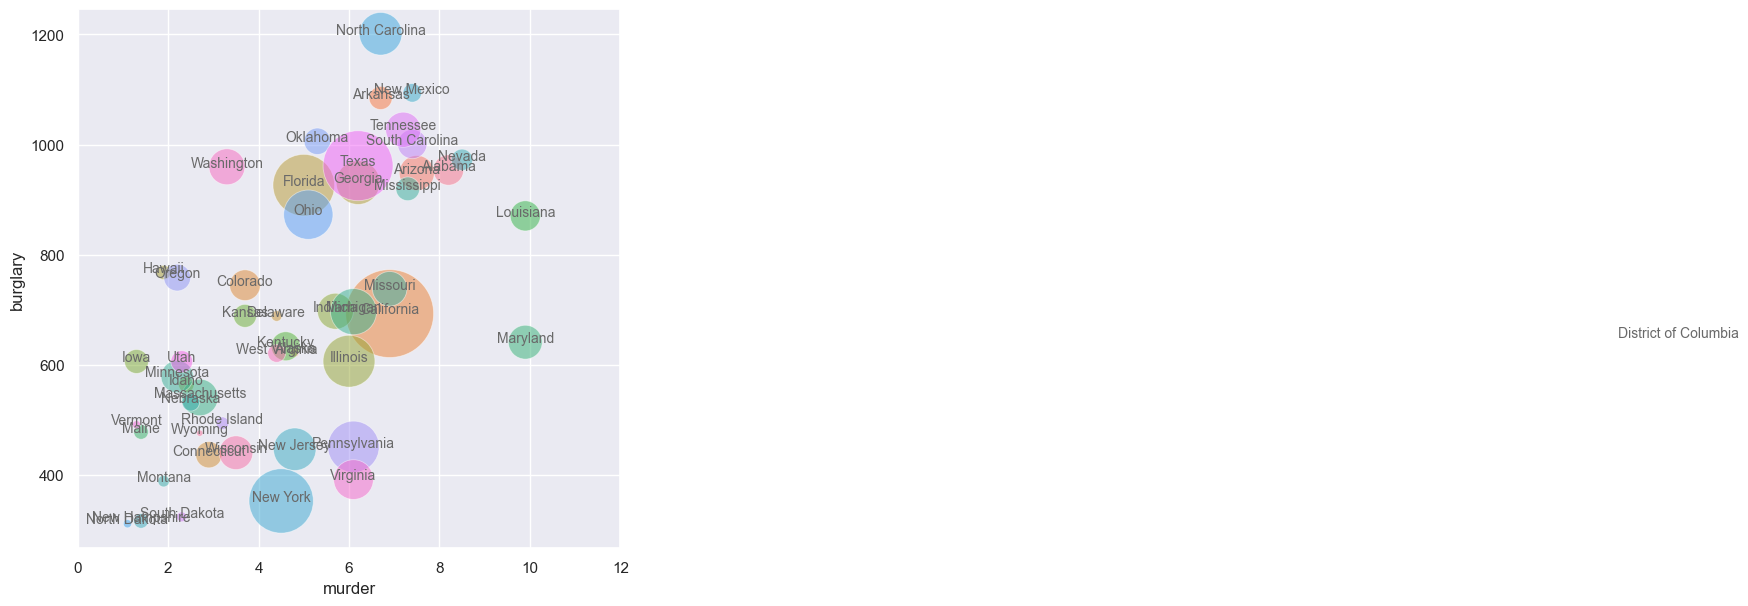

In [21]:
# 8-4
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df=pd.read_csv('data/crimeRatesByState2005.csv')
print(df.head())

sns.set_theme(rc={'figure.figsize': (7, 7)})

sns.scatterplot(
    data=df,
    x="murder",
    y="burglary",
    size="population",
    sizes=(20, 4000),
    hue="state",
    alpha=0.5,
    legend=False
)
plt.xlim(0, 12)
for i in range(0, df.shape[0]):
    plt.text(x=df.murder[i], y=df.burglary[i], s=df.state[i],
             horizontalalignment='center', size='small', color='dimgray')
    
plt.show()

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
  survived  pclass sex   age  sibsp  parch     fare embarked  class    who  \
0       사망       3  남성  22.0      1      0   7.2500        S  Third    man   
1       생존       1  여성  38.0      1      0  71.2833        C  F

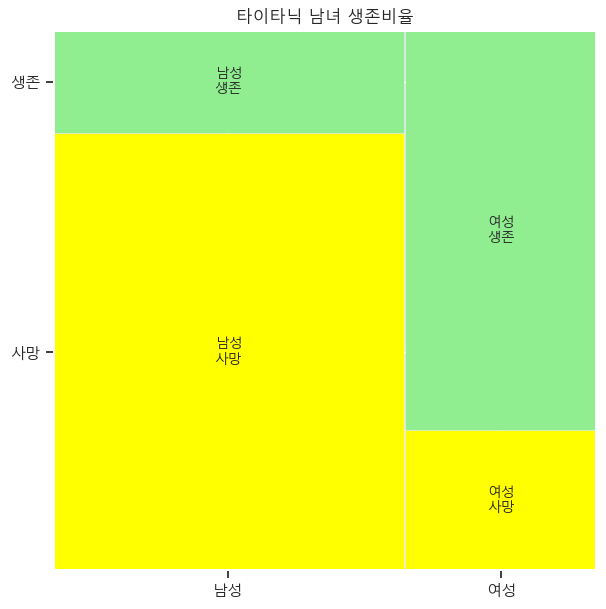

In [23]:
# 8-5
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.mosaicplot import mosaic

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

df = sns.load_dataset('titanic')
print(df.head())
dict1={0:'사망', 1:'생존'}
dict2={'male': '남성', 'female': '여성'}

df=df.replace({'survived': dict1})
df=df.replace({'sex': dict2})
print(df.head())

props = lambda key: {'color': 'lightgreen' if '생존' in key else 'yellow'}

mosaic(data = df.sort_values('sex'),
index = ['sex', 'survived'],
properties = props,
axes_label = True,
title = '타이타닉 남녀 생존비율'
)

plt.show()


   year month  passengers
0  1949   Jan         112
1  1949   Feb         118
2  1949   Mar         132
3  1949   Apr         129
4  1949   May         121
year    1949   1950   1951   1952   1953   1954   1955   1956   1957   1958  \
month                                                                         
Jan    112.0  115.0  145.0  171.0  196.0  204.0  242.0  284.0  315.0  340.0   
Feb    118.0  126.0  150.0  180.0  196.0  188.0  233.0  277.0  301.0  318.0   
Mar    132.0  141.0  178.0  193.0  236.0  235.0  267.0  317.0  356.0  362.0   
Apr    129.0  135.0  163.0  181.0  235.0  227.0  269.0  313.0  348.0  348.0   
May    121.0  125.0  172.0  183.0  229.0  234.0  270.0  318.0  355.0  363.0   

year    1959   1960  
month                
Jan    360.0  417.0  
Feb    342.0  391.0  
Mar    406.0  419.0  
Apr    396.0  461.0  
May    420.0  472.0  


C:\Users\user\AppData\Local\Temp\ipykernel_61248\3550598895.py:8: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df= flights.pivot_table(index = 'month',


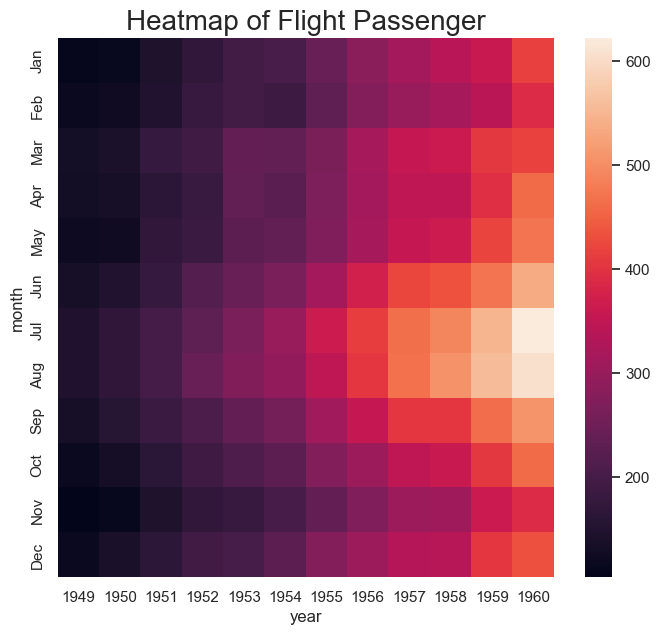

In [24]:
# 8-4
import seaborn as sns
import matplotlib.pyplot as plt

flights = sns.load_dataset('flights')
print(flights.head())

df= flights.pivot_table(index = 'month',
                        columns = 'year',
                        values= 'passengers',
                        aggfunc = 'mean'
                        )
print(df.head())

sns.set_theme(rc={'figure.figsize':(8, 7)})
sns.heatmap(df).set_title('Heatmap of Flight Passenger', fontsize=20)
plt.show()

       Kor  Eng  Math  Sci  Phy
AVG     72   84    71   83   60
John    70   85    40   80   60
Tom     90   95    88   91   60
Smith   60   70    80   90   70
Grace   66   85    75   70   50


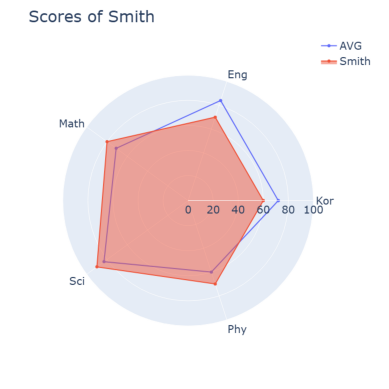

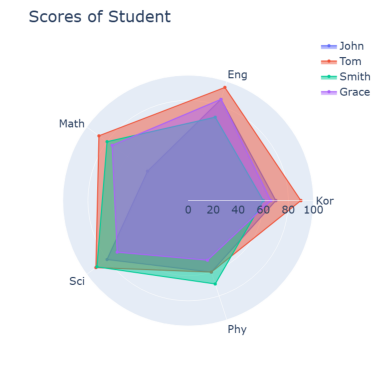

In [1]:
# 8-7
import matplotlib.image as mpimg
import plotly.graph_objects as go
import pandas as pd
import matplotlib.pyplot as plt

def radar(df, fills, min_max, title=''):
    fig = go.Figure()
    categories = df.columns.to_list()
    categories.append(categories[0])
    i = 0
    while (i < len(df)):
        scores = df.iloc[i, :].to_list()
        scores.append(scores[0])
        fig.add_trace(go.Scatterpolar(
            r=scores,  # 축의 값
            theta=categories,  # 축의 레이블
            fill=fills[i],  # 다각형 채우기 색
            name=df.index[i]  # 다각형 레이블
        ))
        i += 1
        
        fig.update_layout(
            polar_radialaxis_visible=True,
            polar_radialaxis_range=min_max,  # 축의 값 범위
            showlegend=True,
            margin_t=50,  # 상단 여백
            margin_l=100,  # 좌측 여백
            margin_r=100,  # 우측 여백
            margin_b=25,  # 하단 여백
            width=700,  # 그래프의 폭(pixel)
            height=700,  # 그래프의 높이(pixel)
            title_text=title,  # 그래프 제목
            title_font_size=30,  # 제목 폰트 사이즈
            font_size=20  # 폰트 사이즈
            )
        
 
    plt.axis('off') 
    fig.write_image('rader.png')
    plt.imshow(mpimg.imread('rader.png'))
    plt.show()

df = pd.DataFrame({
    'Kor':[72, 70, 90, 60, 66],
    'Eng': [84, 85, 95, 70, 85],
    'Math':[71, 40, 88, 80, 75],
    'Sci': [83, 80, 91, 90, 70],
    'Phy': [60, 60, 60, 70, 50]
})
df.index=['AVG', 'John', 'Tom', 'Smith', 'Grace']
print(df)

fills = [None, 'toself']
radar(df=df.iloc[[0, 3], :],
      fills=fills,
      min_max=[0, 100],
      title='Scores of Smith'
      )

fills = ['toself', 'toself', 'toself', 'toself']
radar(df=df.iloc[1:, :],
      fills=fills,
      min_max=[0, 100],
      title='Scores of Student'
      )

True

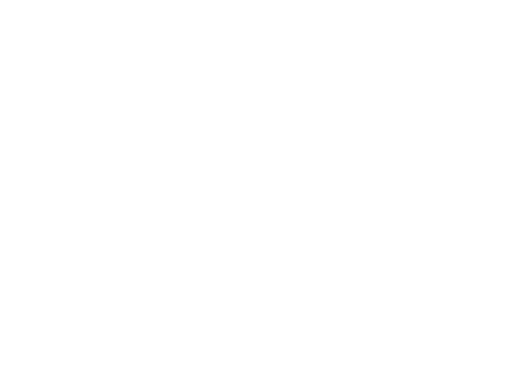

In [4]:
#8.8

import plotly.express as px
import webbrowser
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('data/GNI2014.csv')
df.head()

fig = px.treemap(data_frame=df,
                 path=['continent', 'iso3'],  # 데이터의 계층 구조
                 values='population',  # 타일 면적 기준 컬럼
                 color='GNI',  # 색 온도 기준 컬럼
                 color_continuous_scale='Bluyl'  # 컬러 팔레트
                 )

plt.axis('off')  # 축 눈금 제거
fig.update_layout(margin_t=50, margin_l=25,  # 여백 설정
                  margin_r=25, margin_b=25,
                  width=800,  # 그래프의 폭(pixel)
                  height=600,  # 그래프의 높이(pixel)
                  title_text='GNI 2014',  # 그래프 제목
                  title_font_size=20  # 제목 폰트 크기
                  )

# 그래프 저장 & 화면에 표시하기
fig.write_html('d:/treemap.html')  # html 파일로 결과 저장
webbrowser.open('d:/treemap.html')  # 웹 브라우저에서 그래프 확인
